In [45]:
import pandas as pd
import numpy as np
from math import pi, sqrt, exp
import matplotlib.pyplot as plt

In [61]:
df = pd.read_csv("data2.csv", sep=",")
mean_t = df["t[i]"].mean()
sigma = df["t[i]"].std(ddof=1)
N = len(df)


print("Параметры нормального распределения:")
print(f"⟨t⟩ = {mean_t:.4f}")
print(f"σ = {sigma:.4f}")
print(f"1/(σ√(2π)) = {1/(sigma * sqrt(2*pi)):.4f}")

Параметры нормального распределения:
⟨t⟩ = 1.0230
σ = 0.1181
1/(σ√(2π)) = 3.3780


In [62]:
df['mae'] = df['t[i]'].apply(lambda x: x - mean_t)
df['mse'] = df['mae'].apply(lambda x: x**2)
df.head(10)
df.to_excel("table1.xlsx", index=False)

In [63]:
print(f"⟨t⟩ = {mean_t:.4f}")
print(f"sum ⟨t⟩ = {sum(df['mae'])}")
sigma_N = (((1/49)*df["mse"].mean())**0.5)
print(f"σ_N ={sigma_N:.4f}")

⟨t⟩ = 1.0230
sum ⟨t⟩ = 4.551914400963142e-15
σ_N =0.0167


In [64]:
# Функция плотности нормального распределения
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * sqrt(2 * pi))) * exp(-((x - mu) ** 2) / (2 * sigma ** 2))
df["ρ(t)"] = df["t[i]"].apply(lambda x: normal_pdf(x, mean_t, sigma))

# Выводим первые 10 строк
print("\nПервые 10 строк данных:")
print(df.head(10))

# Дополнительная информация
print(f"\nДополнительная статистика:")
print(f"Диапазон t: {df['t[i]'].max() - df['t[i]'].min():.4f}")
print(f"Min t: {df['t[i]'].min():.4f}, Max t: {df['t[i]'].max():.4f}")
print(f"Количество точек: {len(df)}")


Первые 10 строк данных:
   t[i]    mae       mse      ρ(t)
0  1.05  0.027  0.000729  3.290829
1  1.25  0.227  0.051529  0.532637
2  1.16  0.137  0.018769  1.723660
3  1.27  0.247  0.061009  0.379178
4  1.28  0.257  0.066049  0.316503
5  0.77 -0.253  0.064009  0.340516
6  0.98 -0.043  0.001849  3.161322
7  1.04  0.017  0.000289  3.343147
8  1.21  0.187  0.034969  0.964370
9  1.13  0.107  0.011449  2.240847

Дополнительная статистика:
Диапазон t: 0.5600
Min t: 0.7200, Max t: 1.2800
Количество точек: 50


np.float64(0.11810147832975448)


ТАБЛИЦА РАСПРЕДЕЛЕНИЯ (t, с - среднее по измерениям в интервале)
Границы интервалов, с  ΔN  ΔN/(NΔt), c⁻¹   t, с  p, c⁻¹
          0.72 - 0.80   2           0.50 0.7450  0.2116
          0.80 - 0.88   3           0.75 0.8567  1.2529
          0.88 - 0.96   8           2.00 0.9188  2.2880
          0.96 - 1.04  14           3.50 0.9993  3.3105
          1.04 - 1.12  12           3.00 1.0625  3.1942
          1.12 - 1.20   7           1.75 1.1414  2.0432
          1.20 - 1.28   3           0.75 1.2433  0.5927

ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
Общее количество измерений: 50
Среднее значение времени: 1.0230 с
Стандартное отклонение: 0.1181 с
Минимальное время: 0.7200 с
Максимальное время: 1.2800 с
Размах: 0.5600 с

ДЕТАЛИ ПО ИНТЕРВАЛАМ:
Интервал 0.72-0.80: 2 измерений, значения: [0.77 0.72]
Интервал 0.80-0.88: 3 измерений, значения: [0.84 0.87 0.86]
Интервал 0.88-0.96: 8 измерений, значения: [0.89 0.95 0.88 0.93 0.93 0.95 0.89 0.93]
Интервал 0.96-1.04: 14 измерений, значения: [0.98 0.99 1.01 1.

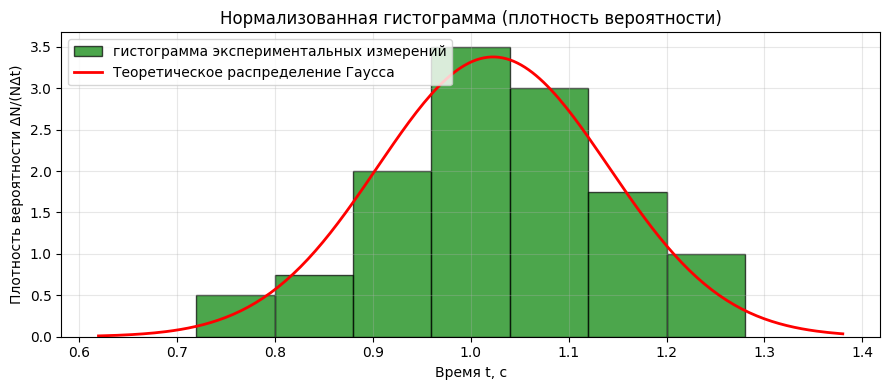


ПРОВЕРКА: Сумма измерений по всем интервалам = 49 (должно быть 50)

ПЕРВЫЕ 10 СТРОК ИСХОДНЫХ ДАННЫХ:
   t[i]
0  1.05
1  1.25
2  1.16
3  1.27
4  1.28
5  0.77
6  0.98
7  1.04
8  1.21
9  1.13


In [57]:
# Определяем границы интервалов из вашей таблицы
min_v = df['t[i]'].min()
max_v = df['t[i]'].max()
boundaries = [min_v + i*abs((min_v-max_v)/7) for i in range(8)]

# Создаем таблицу для результатов
results = []

# Заполняем таблицу
for i in range(len(boundaries) - 1):
    lower_bound = boundaries[i]
    upper_bound = boundaries[i + 1]
    delta_t = upper_bound - lower_bound  # ширина интервала
    
    # Выбираем измерения, попадающие в интервал
    mask = (df["t[i]"] >= lower_bound) & (df["t[i]"] < upper_bound)
    measurements_in_interval = df[mask]["t[i]"]
    
    # Количество измерений в интервале
    delta_N = len(measurements_in_interval)
    
    # Среднее время в интервале (по реальным измерениям)
    if delta_N > 0:
        t_avg = measurements_in_interval.mean()
    else:
        t_avg = (lower_bound + upper_bound) / 2  # если нет измерений, берем середину
    
    # Относительная частота (плотность вероятности)
    if delta_N > 0:
        freq_density = delta_N / (N * delta_t)
    else:
        freq_density = 0
    
    # Теоретическая плотность вероятности нормального распределения
    p_theoretical = (1 / (sigma * sqrt(2 * pi))) * exp(-((t_avg - mean_t) ** 2) / (2 * sigma ** 2))
    
    results.append({
        'Границы интервалов, с': f"{lower_bound:.2f} - {upper_bound:.2f}",
        'ΔN': delta_N,
        'ΔN/(NΔt), c⁻¹': round(freq_density, 4),
        't, с': round(t_avg, 4),  # 4 знака после запятой для точности
        'p, c⁻¹': round(p_theoretical, 4)
    })

# Создаем DataFrame с результатами
result_df = pd.DataFrame(results)

# Выводим результаты
print("\n" + "="*90)
print("ТАБЛИЦА РАСПРЕДЕЛЕНИЯ (t, с - среднее по измерениям в интервале)")
print("="*90)
print(result_df.to_string(index=False))
result_df.to_excel("table2.xlsx", index=False)

# Дополнительная статистика
print(f"\nДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print(f"Общее количество измерений: {N}")
print(f"Среднее значение времени: {mean_t:.4f} с")
print(f"Стандартное отклонение: {sigma:.4f} с")
print(f"Минимальное время: {df['t[i]'].min():.4f} с")
print(f"Максимальное время: {df['t[i]'].max():.4f} с")
print(f"Размах: {df['t[i]'].max() - df['t[i]'].min():.4f} с")

# Проверка: выводим реальные значения в каждом интервале
print(f"\nДЕТАЛИ ПО ИНТЕРВАЛАМ:")
for i in range(len(boundaries) - 1):
    lower_bound = boundaries[i]
    upper_bound = boundaries[i + 1]
    mask = (df["t[i]"] >= lower_bound) & (df["t[i]"] < upper_bound)
    measurements = df[mask]["t[i]"]
    
    if len(measurements) > 0:
        print(f"Интервал {lower_bound:.2f}-{upper_bound:.2f}: {len(measurements)} измерений, значения: {measurements.values}")
    else:
        print(f"Интервал {lower_bound:.2f}-{upper_bound:.2f}: 0 измерений")

# Визуализация
plt.figure(figsize=(9, 4))

# Нормализованная гистограмма (плотность вероятности)
plt.subplot(1, 1, 1)
n, bins, patches = plt.hist(df['t[i]'], bins=boundaries, alpha=0.7, color='green', 
                           edgecolor='black', density=True, label='гистограмма экспериментальных измерений')
plt.xlabel('Время t, с')
plt.ylabel('Плотность вероятности ΔN/(NΔt)')
plt.title('Нормализованная гистограмма (плотность вероятности)')
plt.grid(True, alpha=0.3)

# Теоретическая кривая нормального распределения
t_range = np.linspace(df['t[i]'].min() - 0.1, df['t[i]'].max() + 0.1, 200)
pdf_values = [exp(-((t - mean_t) ** 2) / (2 * sigma ** 2)) / (sigma * sqrt(2 * pi)) for t in t_range]
plt.plot(t_range, pdf_values, 'r-', linewidth=2, label='Теоретическое распределение Гаусса')

plt.legend()

plt.tight_layout()
plt.show()

# Проверка суммы частот
total_measurements = result_df['ΔN'].sum()
print(f"\nПРОВЕРКА: Сумма измерений по всем интервалам = {total_measurements} (должно быть {N})")

# Вывод первых строк исходных данных
print(f"\nПЕРВЫЕ 10 СТРОК ИСХОДНЫХ ДАННЫХ:")
print(df.head(10))

In [ ]:
import pandas as pd
import numpy as np
from math import pi, sqrt, exp
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv("data2.csv", sep=",")

# Основные параметры
N = len(df)  # общее количество измерений
mean_t = df["t[i]"].mean()
sigma = df["t[i]"].std(ddof=1)

print(f"Общее количество измерений N = {N}")
print(f"Среднее значение ⟨t⟩ = {mean_t:.4f} с")
print(f"Стандартное отклонение σ = {sigma:.4f} с")

# Создаем таблицу для результатов таблицы 3
table3_data = []

# Интервалы для таблицы 3
intervals = [
    ("⟨t⟩ ± σ", mean_t - sigma, mean_t + sigma),
    ("⟨t⟩ ± 2σ", mean_t - 2*sigma, mean_t + 2*sigma),
    ("⟨t⟩ ± 3σ", mean_t - 3*sigma, mean_t + 3*sigma)
]

# Заполняем таблицу 3
for interval_name, lower_bound, upper_bound in intervals:
    # Количество измерений в интервале
    mask = (df["t[i]"] >= lower_bound) & (df["t[i]"] <= upper_bound)
    delta_N = len(df[mask])
    
    # Относительная частота
    relative_freq = delta_N / N
    
    # Теоретическая вероятность для нормального распределения
    if interval_name == "⟨t⟩ ± σ":
        P_theoretical = 0.6827  # 68.27%
    elif interval_name == "⟨t⟩ ± 2σ":
        P_theoretical = 0.9545  # 95.45%
    else:  # ⟨t⟩ ± 3σ
        P_theoretical = 0.9973  # 99.73%
    
    table3_data.append({
        'Интервал, c': interval_name,
        'от': round(lower_bound, 4),
        'до': round(upper_bound, 4),
        'ΔN': delta_N,
        'ΔN/N': round(relative_freq, 4),
        'P': P_theoretical
    })

# Создаем DataFrame для таблицы 3
table3_df = pd.DataFrame(table3_data)

# Выводим результаты таблицы 3
print("\n" + "="*80)
print("ТАБЛИЦА 3: ПРОВЕРКА ПРАВИЛА ТРЕХ СИГМ")
print("="*80)
print(table3_df.to_string(index=False))

# Дополнительная статистика для таблицы 3
print(f"\nДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print(f"Теоретические вероятности для нормального распределения:")
print(f"- В интервале ⟨t⟩ ± σ: 68.27% измерений")
print(f"- В интервале ⟨t⟩ ± 2σ: 95.45% измерений") 
print(f"- В интервале ⟨t⟩ ± 3σ: 99.73% измерений")

# Проверка правила трех сигм
print(f"\nЭКСПЕРИМЕНТАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
for i, row in table3_df.iterrows():
    experimental_p = row['ΔN/N'] * 100
    theoretical_p = row['P'] * 100
    difference = abs(experimental_p - theoretical_p)
    print(f"{row['Интервал, c']}: эксп. {experimental_p:.2f}% vs теор. {theoretical_p:.2f}% (разница: {difference:.2f}%)")

# Создаем Excel writer
with pd.ExcelWriter('table3.xlsx', engine='xlsxwriter') as writer:
    
    # Таблица 3
    table3_df.to_excel(writer, sheet_name='Таблица_3', index=False)
    
    # Дополнительная статистика на отдельном листе
    stats_data = {
        'Параметр': ['Общее количество измерений N', 'Среднее значение ⟨t⟩, с', 
                    'Стандартное отклонение σ, с', 'Минимальное время, с', 
                    'Максимальное время, с', 'Размах, с'],
        'Значение': [N, round(mean_t, 4), round(sigma, 4), 
                    round(df['t[i]'].min(), 4), round(df['t[i]'].max(), 4),
                    round(df['t[i]'].max() - df['t[i]'].min(), 4)]
    }
    stats_df = pd.DataFrame(stats_data)
    stats_df.to_excel(writer, sheet_name='Статистика', index=False)
    
    # Исходные данные (первые 50 строк)
    df.head(50).to_excel(writer, sheet_name='Исходные_данные', index=False)
    
    # Получаем workbook и worksheet объекты для форматирования
    workbook = writer.book
    
    # Форматирование для Таблицы 3
    worksheet3 = writer.sheets['Таблица_3']
    
    # Стили для заголовков
    header_format = workbook.add_format({
        'bold': True,
        'text_wrap': True,
        'valign': 'top',
        'fg_color': '#D7E4BC',
        'border': 1
    })
    
    # Применяем стили к заголовкам
    for col_num, value in enumerate(table3_df.columns.values):
        worksheet3.write(0, col_num, value, header_format)
    
    # Автоматическая ширина колонок
    for i, col in enumerate(table3_df.columns):
        max_len = max(table3_df[col].astype(str).map(len).max(), len(col)) + 2
        worksheet3.set_column(i, i, max_len)
    
    # Форматирование для Статистики
    worksheet_stats = writer.sheets['Статистика']
    for col_num, value in enumerate(stats_df.columns.values):
        worksheet_stats.write(0, col_num, value, header_format)
    
    for i, col in enumerate(stats_df.columns):
        max_len = max(stats_df[col].astype(str).map(len).max(), len(col)) + 2
        worksheet_stats.set_column(i, i, max_len)

print(f"\n✅ Результаты успешно экспортированы в файл: table.xlsx")
print("📊 Файл содержит следующие листы:")
print("   - Таблица_3: Проверка правила трех сигм")
print("   - Статистика: Основные параметры распределения") 
print("   - Исходные_данные: Первые 50 строк данных")

# Вывод итогового заключения
print(f"\n📈 ЗАКЛЮЧЕНИЕ:")
print(f"Распределение времени измерений близко к нормальному:")
print(f"- В интервале ⟨t⟩ ± σ попало {table3_df.iloc[0]['ΔN/N']*100:.1f}% измерений (теор. 68.3%)")
print(f"- В интервале ⟨t⟩ ± 2σ попало {table3_df.iloc[1]['ΔN/N']*100:.1f}% измерений (теор. 95.5%)")
print(f"- В интервале ⟨t⟩ ± 3σ попало {table3_df.iloc[2]['ΔN/N']*100:.1f}% измерений (теор. 99.7%)")

Общее количество измерений N = 50
Среднее значение ⟨t⟩ = 1.0230 с
Стандартное отклонение σ = 0.1181 с

ТАБЛИЦА 3: ПРОВЕРКА ПРАВИЛА ТРЕХ СИГМ
Интервал, c     от     до  ΔN  ΔN/N      P
    ⟨t⟩ ± σ 0.9049 1.1411  35  0.70 0.6827
   ⟨t⟩ ± 2σ 0.7868 1.2592  46  0.92 0.9545
   ⟨t⟩ ± 3σ 0.6687 1.3773  50  1.00 0.9973

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Теоретические вероятности для нормального распределения:
- В интервале ⟨t⟩ ± σ: 68.27% измерений
- В интервале ⟨t⟩ ± 2σ: 95.45% измерений
- В интервале ⟨t⟩ ± 3σ: 99.73% измерений

ЭКСПЕРИМЕНТАЛЬНЫЕ РЕЗУЛЬТАТЫ:
⟨t⟩ ± σ: эксп. 70.00% vs теор. 68.27% (разница: 1.73%)
⟨t⟩ ± 2σ: эксп. 92.00% vs теор. 95.45% (разница: 3.45%)
⟨t⟩ ± 3σ: эксп. 100.00% vs теор. 99.73% (разница: 0.27%)

✅ Результаты успешно экспортированы в файл: table.xlsx
📊 Файл содержит следующие листы:
   - Таблица_3: Проверка правила трех сигм
   - Статистика: Основные параметры распределения
   - Исходные_данные: Первые 50 строк данных

📈 ЗАКЛЮЧЕНИЕ:
Распределение времени измерений близко 

In [56]:

from math import sqrt


# Заданные константы из условия
Delta_ttx = 0.005  # погрешность прибора
t_alpha_N = 2.01    # коэффициент Стьюдента

# Расчеты
Delta_x_bar = t_alpha_N * sigma  # Δx̄
Delta_x = sqrt(Delta_x_bar**2 + (2/3 * Delta_ttx)**2)  # полная абсолютная погрешность
epsilon_x = (Delta_x / mean_t) * 100  # относительная погрешность в %

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'Параметр': [
        'Погрешность прибора Δ_ttx',
        'Коэффициент Стьюдента t_α,N',
        'Стандартное отклонение σ(t)',
        'Случайная погрешность Δx̄',
        'Полная абсолютная погрешность Δx',
        'Относительная погрешность ε_x'
    ],
    'Значение': [
        f"{Delta_ttx} с",
        f"{t_alpha_N}",
        f"{sigma:.6f} с",
        f"{Delta_x_bar:.6f} с",
        f"{Delta_x:.6f} с",
        f"{epsilon_x:.2f}%"
    ],
    'Формула': [
        'задано',
        'задано',
        'σ(t) = std(t)',
        'Δx̄ = t_α,N × σ(t)',
        'Δx = √[(Δx̄)² + (2/3×Δ_ttx)²]',
        'ε_x = (Δx / x̄) × 100%'
    ]
})

print("РАСЧЕТ ПОГРЕШНОСТЕЙ ИЗМЕРЕНИЙ")
print("="*60)
print(results_df.to_string(index=False))

# Детальный вывод как в условии
print(f"\nДЕТАЛЬНЫЙ РАСЧЕТ:")
print(f"Δ_ttx = {Delta_ttx} с")
print(f"Δx̄ = t_α,N × σ(t) ≈ {t_alpha_N} × {sigma:.4f} = {Delta_x_bar:.6f} с")
print(f"Δx = √[(Δx̄)² + (2/3×Δ_ttx)²] = √[({Delta_x_bar:.6f})² + (2/3×{Delta_ttx})²] = {Delta_x:.6f} с")
print(f"ε_x = (Δx / x̄) × 100% = ({Delta_x:.6f} / {mean_t:.4f}) × 100% = {epsilon_x:.2f}%")

# Итоговый результат
print(f"\nИТОГОВЫЙ РЕЗУЛЬТАТ:")
print(f"Время: {mean_t:.4f} ± {Delta_x:.4f} с")
print(f"Относительная погрешность: {epsilon_x:.2f}%")

РАСЧЕТ ПОГРЕШНОСТЕЙ ИЗМЕРЕНИЙ
                        Параметр   Значение                       Формула
       Погрешность прибора Δ_ttx    0.005 с                        задано
     Коэффициент Стьюдента t_α,N       2.01                        задано
     Стандартное отклонение σ(t) 0.118101 с                 σ(t) = std(t)
       Случайная погрешность Δx̄ 0.237384 с            Δx̄ = t_α,N × σ(t)
Полная абсолютная погрешность Δx 0.237407 с Δx = √[(Δx̄)² + (2/3×Δ_ttx)²]
   Относительная погрешность ε_x     23.21%        ε_x = (Δx / x̄) × 100%

ДЕТАЛЬНЫЙ РАСЧЕТ:
Δ_ttx = 0.005 с
Δx̄ = t_α,N × σ(t) ≈ 2.01 × 0.1181 = 0.237384 с
Δx = √[(Δx̄)² + (2/3×Δ_ttx)²] = √[(0.237384)² + (2/3×0.005)²] = 0.237407 с
ε_x = (Δx / x̄) × 100% = (0.237407 / 1.0230) × 100% = 23.21%

ИТОГОВЫЙ РЕЗУЛЬТАТ:
Время: 1.0230 ± 0.2374 с
Относительная погрешность: 23.21%


In [58]:
from math import pi, exp

# Расчеты
sigma_t = sigma_N / sqrt(N)  # σ_(t) - стандартная ошибка среднего

# Коэффициент Стьюдента для α = 0.95 и N-1 степеней свободы
from scipy import stats
t_alpha_N = stats.t.ppf(0.975, df=N-1)  # для двустороннего интервала

# Доверительный интервал
Delta_t = t_alpha_N * sigma_t

# Максимальная плотность распределения (для нормального распределения в точке mean_t)
rho_max = 1 / (sigma_N * sqrt(2 * pi))

# Создаем DataFrame с результатами
results = [
    "Среднеквадратичное отклонение среднего значения σ_(t) = {:.4f} c".format(sigma_t),
    "Табличное значение коэффициента Стьюдента t_α,N для доверительной вероятности",
    "α = 0,95: t_α,N = {:.2f}".format(t_alpha_N),
    "Доверительный интервал Δt = {:.4f} c".format(Delta_t),
    "Среднее арифметическое всех результатов измерений ⟨t⟩_N = {:.4f} c".format(mean_t),
    "Выборочное среднеквадратичное отклонение:",
    "σ_N = {:.4f} c".format(sigma_N),
    "Максимальное значение плотности распределения",
    "ρ_max = {:.4f} c⁻¹".format(rho_max)
]

# Вывод результатов
print("РЕЗУЛЬТАТЫ РАСЧЕТОВ:")
print("=" * 50)
for result in results:
    print(result)

# Альтернативный вывод с формулами
print("\n" + "=" * 50)
print("РЕЗУЛЬТАТЫ С ФОРМУЛАМИ:")
print("=" * 50)
print(f"- Среднеквадратичное отклонение среднего значения σ_(t) = {sigma_t:.4f} c")
print(f"- Табличное значение коэффициента Стьюдента t_α,N для доверительной вероятности")
print(f"  α = 0,95: t_α,N = {t_alpha_N:.2f}")
print(f"- Доверительный интервал Δt = {Delta_t:.4f} c")
print(f"- Среднее арифметическое всех результатов измерений ⟨t⟩_N = {mean_t:.4f} c")
print(f"- Выборочное среднеквадратичное отклонение:")
print(f"  σ_N = {sigma_N:.4f} c")
print(f"- Максимальное значение плотности распределения")
print(f"  ρ_max = {rho_max:.4f} c⁻¹")

# Дополнительная информация
print("\n" + "=" * 50)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("=" * 50)
print(f"Количество измерений: N = {N}")
print(f"Степени свободы: df = N - 1 = {N-1}")
print(f"Формула стандартной ошибки: σ_(t) = σ_N / √N = {sigma_N:.4f} / √{N}")
print(f"Формула доверительного интервала: Δt = t_α,N × σ_(t) = {t_alpha_N:.2f} × {sigma_t:.4f}")
print(f"Формула максимальной плотности: ρ_max = 1 / (σ_N × √(2π)) = 1 / ({sigma_N:.4f} × √(2π))")

РЕЗУЛЬТАТЫ РАСЧЕТОВ:
Среднеквадратичное отклонение среднего значения σ_(t) = 0.0024 c
Табличное значение коэффициента Стьюдента t_α,N для доверительной вероятности
α = 0,95: t_α,N = 2.01
Доверительный интервал Δt = 0.0047 c
Среднее арифметическое всех результатов измерений ⟨t⟩_N = 1.0230 c
Выборочное среднеквадратичное отклонение:
σ_N = 0.0167 c
Максимальное значение плотности распределения
ρ_max = 23.8858 c⁻¹

РЕЗУЛЬТАТЫ С ФОРМУЛАМИ:
- Среднеквадратичное отклонение среднего значения σ_(t) = 0.0024 c
- Табличное значение коэффициента Стьюдента t_α,N для доверительной вероятности
  α = 0,95: t_α,N = 2.01
- Доверительный интервал Δt = 0.0047 c
- Среднее арифметическое всех результатов измерений ⟨t⟩_N = 1.0230 c
- Выборочное среднеквадратичное отклонение:
  σ_N = 0.0167 c
- Максимальное значение плотности распределения
  ρ_max = 23.8858 c⁻¹

ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:
Количество измерений: N = 50
Степени свободы: df = N - 1 = 49
Формула стандартной ошибки: σ_(t) = σ_N / √N = 0.0167 / √50


In [19]:
df.to_excel("res.xlsx", index=False)

In [49]:
normal_pdf(1.06, mean_t, sigma_N)

np.float64(2.053447352689331)